In [ ]:
from uqregressors.bayesian.deep_ens import DeepEnsembleRegressor
import torch
from dataclasses import dataclass
import numpy as np 
import torch.nn as nn

@dataclass 
class SyntheticFunction: 
    f: callable 
    bounds: np.ndarray 
    noise: float = 0.0 

    def sample(self, X): 
        y = self.f(X)
        if self.noise > 0: 
            y += self.noise * np.random.randn(*y.shape)
        return y

    def __call__(self, X):
        return self.sample(X)

@dataclass 
class PoolDataset: 
    X_pool: np.ndarray 
    y_pool: np.ndarray 
    X_test: np.ndarray 
    y_test = np.ndarray 

from uqregressors.bayesian.deep_ens import DeepEnsembleRegressor
from uqregressors.utils.data_loader import validate_and_prepare_inputs, validate_X_input

class GrubsDeepEnsembleRegressor(DeepEnsembleRegressor): 
    def return_last_layer_grads(self, X): 
        if self.requires_grad: 
            requires_grad_flag = False 
        else: 
            self.requires_grad = True
            requires_grad_flag = True 

        X_tensor = validate_X_input(X, input_dim=self.input_dim, device=self.device, requires_grad=True)
        if self.scale_data: 
            X_tensor = self.input_scaler.transform(X_tensor)

        _, pseudo_y, _ = self.predict(X_tensor)
        pseudo_y = pseudo_y.detach()
        if self.scale_data: 
            pseudo_y = self.output_scaler.transform(pseudo_y)

        grads_list = [] 

        for model in self.models: 
            model.eval() 
            model.zero_grad() 

            X_tensor_grad = validate_X_input(X, input_dim=self.input_dim, device=self.device, requires_grad=True)
            if self.scale_data: 
                X_tensor_grad = self.input_scaler.transform(X_tensor_grad)

            pred = model(X_tensor_grad)
            loss = self.nll_loss(pred, pseudo_y)

            last_linear = None 
            for layer in reversed(model.model): 
                if isinstance(layer, nn.Linear): 
                    last_linear = layer 
                    break 

            assert last_linear is not None, "No final linear layer found" 

            grad_w, grad_b = torch.autograd.grad(
                outputs=loss, 
                inputs=[last_linear.weight, last_linear.bias], 
                create_graph=True, 
                retain_graph=True
            )

            grad_vector = grad_w[0].flatten() 
            grad_vector = grad_vector / (grad_vector.norm() + 1e-8)
            grads_list.append(grad_vector)
            #for i in range(2):
            #    grad_vector = torch.cat([grad_w[i].flatten(), grad_b[i].flatten()], dim=0)
            #    grad_vector = grad_vector / (grad_vector.norm() + 1e-8)
            #    grads_list.append(grad_vector)
    
        if requires_grad_flag: 
            self.requires_grad = False 

        return grads_list
    def get_last_layer_embeddings(self, X): 
        X_tensor = validate_X_input(
            X, input_dim=self.input_dim, device=self.device, requires_grad=True
        )

        if self.scale_data: 
            X_tensor_scaled = self.input_scaler.transform(X_tensor)
        else: 
            X_tensor_scaled = X_tensor

        embeddings = []

        for model in self.models: 
            activations = {} 
            
            def hook_fn(module, input, output):
                activations["h"] = input[0]

            # find last linear
            last_linear = None
            for layer in reversed(model.model):
                if isinstance(layer, torch.nn.Linear):
                    last_linear = layer
                    break

            handle = last_linear.register_forward_hook(hook_fn)

            _ = model(X_tensor_scaled)

            handle.remove()

            embeddings.append(activations["h"].squeeze())
            #print(activations["h"].shape)
        return embeddings


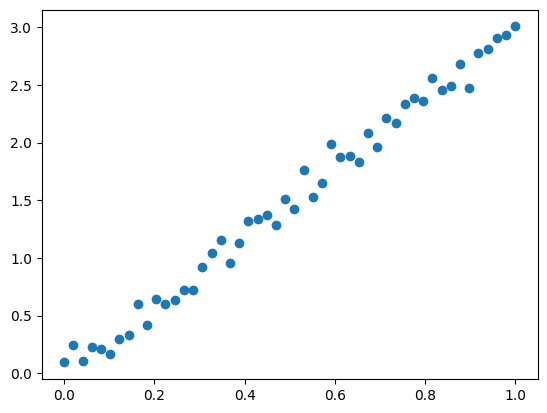

In [34]:
import torch 
import numpy as np 
import matplotlib.pyplot as plt

DE = GrubsDeepEnsembleRegressor(
    hidden_sizes = [16, 5], 
    alpha = 0.1, 
    requires_grad = True, 
    learning_rate = 1e-1,
    epochs=100, 
    optimizer_cls = torch.optim.Adam, 
    scheduler_cls = torch.optim.lr_scheduler.CosineAnnealingLR, 
    scale_data=True
)

x_train = np.linspace(0, 1, 50).reshape(50, 1)
y_train = 3 * x_train + np.random.normal(0, 0.09, size=(len(x_train), 1))

plt.figure() 
plt.scatter(x_train.ravel(), y_train)
plt.show()

In [35]:
DE.fit(x_train, y_train)
grads = DE.return_last_layer_grads([0.5])
embeddings = DE.get_last_layer_embeddings([0.5])

[Estimator-0] epoch=0, train_loss=0.941151887178421, lr=0.1
[Estimator-0] epoch=5, train_loss=-0.644939661026001, lr=0.09938441702975688
[Estimator-0] epoch=10, train_loss=-0.8439835906028748, lr=0.09755282581475769
[Estimator-0] epoch=15, train_loss=-1.8734129965305328, lr=0.0945503262094184
[Estimator-0] epoch=20, train_loss=-0.6642232537269592, lr=0.09045084971874741
[Estimator-0] epoch=25, train_loss=-0.6567105054855347, lr=0.08535533905932739
[Estimator-0] epoch=30, train_loss=-1.40603506565094, lr=0.07938926261462369
[Estimator-0] epoch=35, train_loss=-2.174560070037842, lr=0.07269952498697736
[Estimator-0] epoch=40, train_loss=-2.4984947443008423, lr=0.0654508497187474
[Estimator-0] epoch=45, train_loss=-3.2033365964889526, lr=0.057821723252011584
[Estimator-0] epoch=50, train_loss=-3.1136845350265503, lr=0.05000000000000003
[Estimator-0] epoch=55, train_loss=-3.535833954811096, lr=0.04217827674798848
[Estimator-0] epoch=60, train_loss=-3.4411590099334717, lr=0.03454915028125267

In [36]:
print(grads)
print(embeddings)

[tensor([0.6873, 0.0000, 0.6905, 0.0000, 0.2254], grad_fn=<DivBackward0>), tensor([0.0000, 0.5976, 0.6563, 0.0000, 0.4607], grad_fn=<DivBackward0>), tensor([0., 0., 0., 0., 1.], grad_fn=<DivBackward0>), tensor([0.6625, 0.0000, 0.0000, 0.7491, 0.0000], grad_fn=<DivBackward0>), tensor([0.5838, 0.0000, 0.8119, 0.0000, 0.0000], grad_fn=<DivBackward0>)]
[tensor([[1.8784, 0.0000, 1.8870, 0.0000, 0.6160]], grad_fn=<ReluBackward0>), tensor([[0.0000, 1.0579, 1.1618, 0.0000, 0.8155]], grad_fn=<ReluBackward0>), tensor([[0.0000, 0.0000, 0.0000, 0.0000, 6.3302]], grad_fn=<ReluBackward0>), tensor([[1.7669, 0.0000, 0.0000, 1.9980, 0.0000]], grad_fn=<ReluBackward0>), tensor([[0.9249, 0.0000, 1.2863, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)]
